# 1 · Quantum Boltzmann machines: theory and your first model

This notebook introduces **quantum Boltzmann machines (QBMs)** and the design idea
behind `qbmkit`. By the end you will have built a QBM, inspected its thermal state,
and met the one numerical primitive the whole library is built on.

## What is a QBM?

A QBM is a **parameterized Gibbs (thermal) state**

$$\rho(\theta) = \frac{e^{-G(\theta)}}{Z(\theta)}, \qquad
  G(\theta) = \sum_j \theta_j\, G_j, \qquad
  Z(\theta) = \mathrm{Tr}\, e^{-G(\theta)} ,$$

where the $G_j$ are fixed Hermitian **generators** (Pauli strings) and the
$\theta_j$ are trainable real parameters. When the $G_j$ all commute (only $Z$-type
terms) this is exactly a **classical Boltzmann machine**; allowing non-commuting
terms (e.g. transverse $X$ fields) makes it genuinely quantum.

## The unifying idea

Every task — generative modelling, ground-state energy, state learning,
free-energy minimisation — is the *same* object $\rho(\theta)$ viewed through a
different **loss**, trained by an **optimizer**, on a swappable **backend**. And
every gradient and every quantum-Fisher-information metric reduces to one
primitive: the **belief-propagation channel**

$$\Phi_\theta(X) = \int dt\, p(t)\, e^{-iG t} X\, e^{+iG t}, \qquad
  p(t) = \tfrac{2}{\pi}\ln\!\left|\coth\tfrac{\pi t}{2}\right| .$$

In the eigenbasis of $G$ this is *exact* and diagonal: it just multiplies matrix
element $(k,l)$ by $\varphi(w_k - w_l)$ with $\varphi(\Delta) = \frac{2}{\Delta}\tanh\frac{\Delta}{2}$.
We plot it below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qbm
print("qbmkit version:", qbm.__version__)

qbmkit version: 0.1.0


### The belief-propagation multiplier $\varphi(\Delta)$

This single function is the Fourier transform of the high-peak-tent density
$p(t)$. Implementing it once gives us all gradients and all metrics.

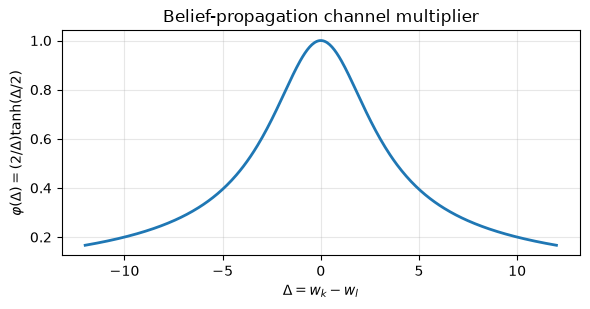

In [2]:
from qbm.channels import bp_multiplier

delta = np.linspace(-12, 12, 400)
phi = np.where(np.abs(delta) < 1e-9, 1.0, (2/delta)*np.tanh(delta/2))

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(delta, phi, lw=2)
ax.set_xlabel(r"$\Delta = w_k - w_l$")
ax.set_ylabel(r"$\varphi(\Delta) = (2/\Delta)\tanh(\Delta/2)$")
ax.set_title("Belief-propagation channel multiplier")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Build a QBM and look at its thermal state

We build a small fully-visible QBM. Its default generators are local fields
$Z_i$, $X_i$ and nearest-neighbour couplings $Z_iZ_{i+1}$.

In [3]:
model = qbm.FullyVisibleQBM(n=3)
print(model)
print("number of parameters:", model.n_params)
print("generator labels:", model.ham.labels)

# pick some parameters and inspect the resulting Gibbs state
rng = np.random.default_rng(1)
model.theta = rng.normal(scale=0.6, size=model.n_params)
state = model.state()
print("log Z      =", round(state.log_partition(), 4))
print("entropy    =", round(state.entropy(), 4))
print("<Z0Z1>     =", round(state.expect(qbm.pauli('ZZI')), 4))

FullyVisibleQBM(n_qubits=3, n_params=8)
number of parameters: 8
generator labels: ['ZII', 'IZI', 'IIZ', 'XII', 'IXI', 'IIX', 'ZZI', 'IZZ']
log Z      = 2.7644
entropy    = 1.5275
<Z0Z1>     = 0.302


### The thermal state's spectrum and measured distribution

The eigenvalues of $G(\theta)$ determine the Boltzmann populations
$p_k = e^{-(w_k-w_0)}/\tilde Z$. The computational-basis probabilities are the
diagonal of $\rho$ and are what we measure / sample.

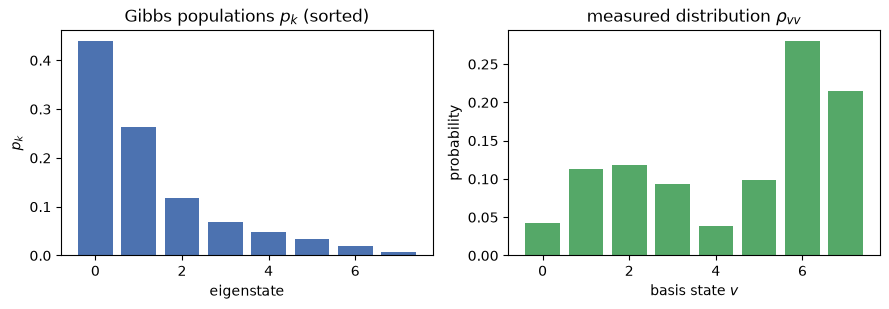

probabilities sum to 1.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].bar(range(len(state.p)), np.sort(state.p)[::-1], color="#4C72B0")
axes[0].set_title("Gibbs populations $p_k$ (sorted)")
axes[0].set_xlabel("eigenstate"); axes[0].set_ylabel("$p_k$")

probs = model.probabilities()
axes[1].bar(range(len(probs)), probs, color="#55A868")
axes[1].set_title("measured distribution $\\rho_{vv}$")
axes[1].set_xlabel("basis state $v$"); axes[1].set_ylabel("probability")
plt.tight_layout(); plt.show()
print("probabilities sum to", round(probs.sum(), 12))

### Recap

- A QBM is the Gibbs state of a parameterized Hamiltonian.
- `qbmkit` builds it by **eigendecomposition** of $G(\theta)$ (overflow-safe, and
  one factorization powers the state, the channel, all gradients and all metrics).
- Next: train a QBM to model a distribution.